|                |   |
:----------------|---|
| **Nombre**     |Carlos Enrique Nieves Ochoa|
| **Fecha**      |8 de octubre de 2026|
| **Expediente** |758210| 

**1. Cargar los rostros**

Cargo los rostros de personas con al menos 60 fotos, después reviso sus nombres y las dimensiones de las imágenes.

In [21]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Quedan 8 personas y 1348 imágenes de 62×47 px.

**2. Mostrar las imágenes**

Muestro las primeras 15 fotos con el nombre real de cada persona, quito las marcas de los ejes para verlas mejor.

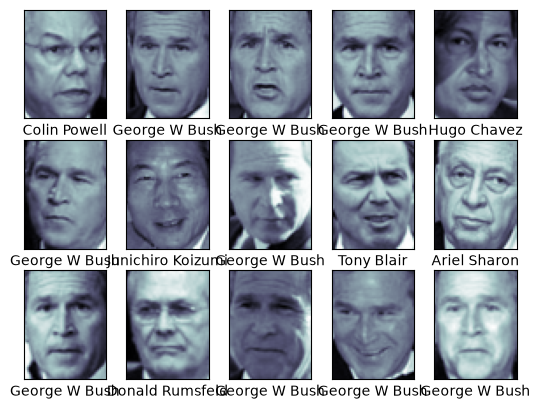

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(3, 5)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

**3. Preparar el modelo**

Configuro PCA con 150 componentes y whiten para ajustar su escala, lo uno con SVC usando RBF y mayor peso para las clases menos frecuentes.

In [23]:

from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.pipeline import make_pipeline

pca = RandomizedPCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

- PCA se ajusta solo con datos de entrenamiento para no filtrar información del conjunto de prueba.
- whiten=True normaliza la varianza de cada componente para que SVC no se deje llevar por las que tienen escalas más grandes.

**4. Separar los datos**

Separo aproximadamente 75% para entrenar y 25% para probar, uso random_state igual a 42 para repetir la misma división.

In [24]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target, random_state=42)

**5. Buscar los mejores parámetros**

Comparo 16 combinaciones de C y gamma con validación cruzada usando solo entrenamiento, muestro la mejor combinación y cuánto tarda la búsqueda.

In [25]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: total: 1min 16s
Wall time: 16.4 s
{'svc__C': 5, 'svc__gamma': 0.001}


Cada combinación hace una validación cruzada completa, por eso tarda más conforme agregas valores.

**6. Hacer las predicciones**

Uso el mejor pipeline ya entrenado para predecir quién aparece en cada foto de prueba, guardo las predicciones en yfit.

In [26]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

**7. Mostrar aciertos y errores**

Muestro 24 fotos de prueba con su forma de 62 por 47, pongo la última parte del nombre predicho en negro si acierta y en rojo si falla.

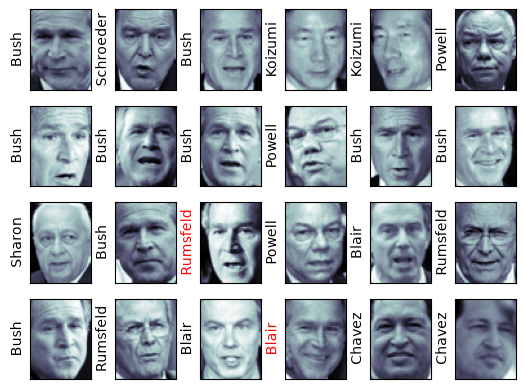

In [27]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                   color='black' if yfit[i] == ytest[i] else 'red')

**8. Evaluar el modelo**

Comparo las etiquetas reales con las predicciones, el reporte muestra precisión, recall, F1 y cuántas fotos de prueba hay por persona.

In [28]:

from sklearn.metrics import classification_report
print(classification_report(ytest, yfit,
                            target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



Bush y Koizumi salen bien clasificados; Hugo Chávez tiene el recall más bajo (0.70), probablemente por tener menos fotos.

**9. Mostrar la matriz de confusión**

Muestro cuántos casos clasifica en cada grupo, por usar mat.T las clases reales quedan en horizontal y las predichas en vertical, la diagonal muestra los aciertos.

<Axes: >

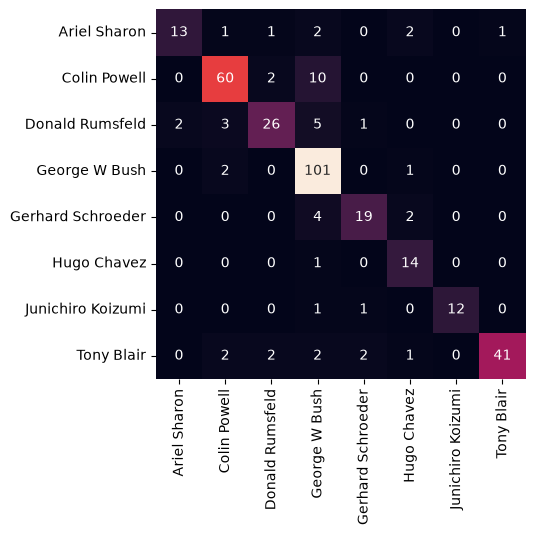

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)

**10. Cargar los dígitos**

Cargo el dataset de dígitos y reviso sus clases y las dimensiones de sus imágenes para repetir el proceso anterior.

In [30]:
from sklearn import datasets
data = datasets.load_digits()
print(data.target_names)
print(data.images.shape)

[0 1 2 3 4 5 6 7 8 9]
(1797, 8, 8)


**11. Mostrar los dígitos**

Muestro las primeras 15 imágenes con su dígito real debajo, así reviso cómo se ven los datos.

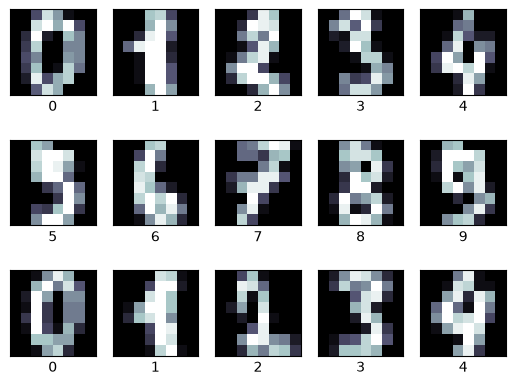

In [31]:
fig, ax = plt.subplots(3, 5)

for i, axi in enumerate(ax.flat):
    axi.imshow(data.images[i], cmap="bone")
    axi.set(
        xticks=[], yticks=[],
        xlabel=str(data.target_names[data.target[i]])
    )

**12. Preparar el modelo de dígitos**

Uso PCA para pasar de 64 características a 30 componentes y lo uno con SVC, cambio los nombres de las variables para conservar el modelo de rostros.

In [32]:
pca_d = RandomizedPCA(n_components=30, whiten=True, random_state=42)

svc_d = SVC(kernel="rbf", class_weight="balanced")

model_d = make_pipeline(pca_d, svc_d)

**13. Separar los datos de dígitos**

Separo los datos en entrenamiento y prueba, mantengo random_state igual a 42 para repetir la misma división.

In [33]:
Xtrain_d, Xtest_d, ytrain_d, ytest_d = train_test_split(data.data, data.target, random_state=42)

**14. Buscar los parámetros**

Comparo las mismas combinaciones de C y gamma con validación cruzada usando solo entrenamiento, muestro la mejor combinación y el tiempo de búsqueda.

In [34]:
param_grid_d = {
    "svc__C": [1, 5, 10, 50],
    "svc__gamma": [0.0001, 0.0005, 0.001, 0.005]
}

grid_d = GridSearchCV(model_d, param_grid_d)

%time grid_d.fit(Xtrain_d, ytrain_d)

print(grid_d.best_params_)

CPU times: total: 3.31 s
Wall time: 3.41 s
{'svc__C': 5, 'svc__gamma': 0.005}


**15. Predecir los dígitos**

Uso el mejor pipeline para predecir los dígitos del conjunto de prueba, guardo los resultados en yfit_d.

In [35]:
model_d = grid_d.best_estimator_

yfit_d = model_d.predict(Xtest_d)

**16. Mostrar las predicciones**

Muestro 24 imágenes con su forma de 8 por 8, pongo el dígito predicho en negro si acierta y en rojo si falla.

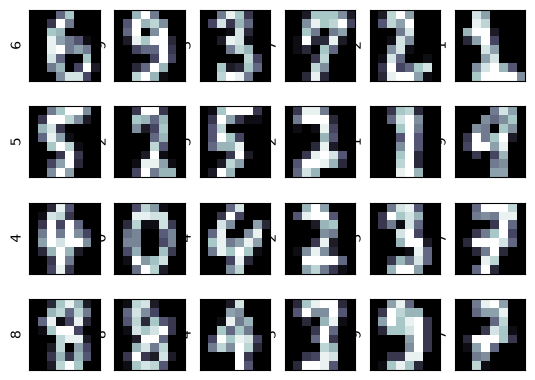

In [36]:
fig, ax = plt.subplots(4, 6)

for i, axi in enumerate(ax.flat):
    axi.imshow(Xtest_d[i].reshape(8, 8), cmap="bone")
    axi.set(xticks=[], yticks=[])
    axi.set_ylabel(
        str(yfit_d[i]),
        color="black" if yfit_d[i] == ytest_d[i] else "red"
    )

**17. Evaluar las predicciones**

Muestro el reporte con precisión, recall, F1 y cantidad de casos por dígito, convierto los nombres de las clases a texto para mostrarlos.

In [37]:
print(classification_report(
    ytest_d,
    yfit_d,
    target_names=data.target_names.astype(str)
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       0.97      1.00      0.99        37
           2       1.00      1.00      1.00        38
           3       1.00      0.96      0.98        46
           4       1.00      1.00      1.00        55
           5       0.97      0.98      0.97        59
           6       0.98      0.98      0.98        45
           7       1.00      0.98      0.99        41
           8       0.95      1.00      0.97        38
           9       0.98      0.96      0.97        48

    accuracy                           0.98       450
   macro avg       0.98      0.99      0.98       450
weighted avg       0.98      0.98      0.98       450



Casi todas las clases están arriba de 0.96 de F1.

**18. Revisar las confusiones**

Muestro la matriz con los dígitos reales en horizontal y los predichos en vertical, la diagonal muestra los aciertos y las demás casillas las confusiones.

<Axes: >

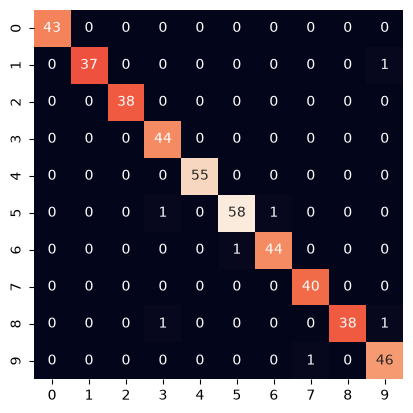

In [38]:
mat_d = confusion_matrix(ytest_d, yfit_d)

sns.heatmap(mat_d.T, square=True, annot=True, fmt="d", cbar=False, xticklabels=data.target_names, yticklabels=data.target_names
)

## References

1. Scikit-learn developers. (n.d.). sklearn.datasets.fetch_lfw_people. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html#sklearn.datasets.fetch_lfw_people

2. Scikit-learn developers. (n.d.). SVM kernels. Scikit-learn. https://scikit-learn.org/stable/modules/svm.html#svm-kernels

3. Scikit-learn developers. (n.d.). sklearn.svm.SVC. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

4. Scikit-learn developers. (n.d.). sklearn.decomposition.PCA. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA